## Scenario: Gourmetshop

Sei l'analista dati di **"Gourmetshop"**, una catena di prodotti alimentari Gourmet con 4 punti vendita in Italia (*Roma, Milano, Napoli, Bologna*). 

Il direttore ti consegna i dati grezzi delle vendite degli ultimi 6 mesi (gennaio-giugno 2024), composti da 300 transazioni, e ti chiede di:
1. **TRASFORMARLI** 2. **VISUALIZZARLI** in 4 grafici chiave.

## Test Finale (3/3)

1. **Ispezionare il dataset** (es. "quante righe ha il dataset?", "ci sono valori mancanti?" e "qual è il prezzo medio di listino?")
2. **Aggiungere colonne calcolate:** il prezzo dopo lo sconto, il fatturato, il costo totale sostenuto dal negozio (prezzo listino + costo acquisto + quantità), il margine assoluto in euro e il margine percentuale.
3. **Usare GroupBy con aggregazione multipla** (uno per categoria (fatturato totale, margine medio, numero transazioni, sconto medio, margine % medio ), uno per negozio (fatturato e margine totale, fatturato medio) e uno per negozio + mese insieme (per il trend temporale)
4. **Costruire una Pivot Table** (fatturato totale per negozio × mese (con totali di riga e colonna grazie a `margins=True`) e margine percentuale medio per categoria × negozio
5. **Filtrare righe con condizioni booleane** (filtra le transazioni con sconto ≥ 20% per analizzare se le scontistiche alte erodono il margine, e poi le transazioni del negozio di Roma nella sola categoria Formaggi)

### Visualizzazione grafica: produrre a scelta almeno 2 dei 4 grafici elencati

6. **Creare un Istogramma:** costruire un istogramma con `sns.histplot()`, `bins= 25`, aggiungere linee verticali per media e mediana con `ax.axvline()`, curva KDE
7. **Creare un Grafico a Barre:** creare sia barre verticali (`ax.bar()`) sia barre orizzontali (`ax.barh()`), scegliere un colore di evidenziazione per la barra più alta, aggiungere etichette numeriche sopra o accanto alle barre e affiancare due pannelli con `plt.subplots(1, 2)`.
8. **Creare un Grafico Lineare:** disegnare più linee sullo stesso asse con `ax.plot()` in un ciclo for, assegnare a ogni linea un colore e un marker diverso, forzando l'ordine diverso dei mesi su asse (grafico lineare)
9. **Creare uno Scatter Plot** e visualizzare indice di correlazione

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# Stile globale: vale per tutti i grafici del file
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.05)

# Seed fisso: tutti gli studenti ottengono lo stesso dataset
np.random.seed(55)

n = 300

negozi = ["Roma", "Milano", "Napoli", "Bologna"]
categorie = ["Formaggi", "Salumi", "Vini", "Olio & Conserve", "Dolci Artigianali"]

df_raw = pd.DataFrame({
    # Data: una transazione ogni ~15 ore nell'arco di 6 mesi
    "data": pd.date_range("2024-01-05", periods=n, freq="15h"),
    
    "negozio": np.random.choice(negozi, n, p=[0.30, 0.28, 0.22, 0.20]),
    "categoria": np.random.choice(categorie, n, p=[0.25, 0.20, 0.22, 0.18, 0.15]),
    
    # Prezzo di listino (€): varia per categoria alimentare
    "prezzo_listino": np.round(
        np.random.choice([12.9, 24.9, 39.9, 59.9, 89.9, 129.9], n,
                         p=[0.22, 0.25, 0.22, 0.17, 0.09, 0.05])
        + np.random.normal(0, 5, n),
        2
    ).clip(8, 200),

    # Quantità acquistata per transazione
    "quantita": np.random.randint(1, 6, n),
    # Sconto applicato (0% = nessuno, max 40%)
    "sconto_pct": np.random.choice(
        [0, 5, 10, 15, 20, 30, 40], n,
        p=[0.30, 0.15, 0.20, 0.15, 0.10, 0.07, 0.03]
    ),

    # Costo di acquisto dal fornitore (40%-65% del prezzo di listino)
    "costo_acquisto": np.round(np.random.uniform(0.40, 0.65, n), 2),
})

print("=" * 60)
print("PARTE 0 - Dataset grezzo GourmetShop")
print("=" * 60)
print(f"\nDimensioni: {df_raw.shape[0]} righe x {df_raw.shape[1]} colonne")
print("\nPrime 5 righe:")
print(df_raw.head())

PARTE 0 - Dataset grezzo GourmetShop

Dimensioni: 300 righe x 7 colonne

Prime 5 righe:
                 data  negozio          categoria  prezzo_listino  quantita  \
0 2024-01-05 00:00:00     Roma  Dolci Artigianali           17.43         2   
1 2024-01-05 15:00:00  Bologna               Vini           58.70         1   
2 2024-01-06 06:00:00   Milano               Vini           65.64         5   
3 2024-01-06 21:00:00     Roma  Dolci Artigianali           17.65         3   
4 2024-01-07 12:00:00   Milano    Olio & Conserve           18.47         3   

   sconto_pct  costo_acquisto  
0          20            0.61  
1           5            0.57  
2           0            0.64  
3          20            0.46  
4          10            0.43  


1. **Ispezionare il dataset** (es. "quante righe ha il dataset?", "ci sono valori mancanti?" e "qual è il prezzo medio di listino?")

In [ ]:
# creiamo una copia del dataaset per le successive elaborazioni

df = df_raw.copy()

## Ispezionaiamo il dataset
print("--- PUNTO 1: Ispezione del Dataset ---")
print(f"Numero di righe: {df.shape[0]}")
print(f"Valori mancanti per colonna:\n{df.isnull().sum()}\n")
print(f"Prezzo medio di listino: {df['prezzo_listino'].mean():.2f} €")
print("-" * 60)

--- PUNTO 1: Ispezione del Dataset ---
Numero di righe: 300
Valori mancanti per colonna:
data              0
negozio           0
categoria         0
prezzo_listino    0
quantita          0
sconto_pct        0
costo_acquisto    0
dtype: int64

Prezzo medio di listino: 38.10 €
------------------------------------------------------------


2. **Aggiungere colonne calcolate:** il prezzo dopo lo sconto, il fatturato, il costo totale sostenuto dal negozio (prezzo listino + costo acquisto + quantità), il margine assoluto in euro e il margine percentuale.

In [ ]:
# 2. aggiunta colonna calcolta

# prezzo dopo lo sconto unitario
df['prezzo_scontato'] = df['prezzo_listino'] * (1 - df['sconto_pct'] / 100)

# Fatturato totale per transazione
df["fatturato"] = df["prezzo_scontato"] * df["quantita"]

# calcola costi totali sostenuti dal negozio
df['costo_unitario_negozio'] = df['prezzo_listino'] * df['costo_acquisto']
df['costo_totale'] = df['costo_unitario_negozio'] * df['quantita']

# Margine Assoluto (€)
df['margine_assoluto'] = df['fatturato'] - df['costo_totale']

# Margine Percentuale (%) 
df['margine_percentuale'] = (df['margine_assoluto'] / df['fatturato']) * 100

print("\n--- PUNTO 2: Prime 3 righe con colonne calcolate ---")
print(df[['prezzo_listino', 'sconto_pct', 'fatturato', 'costo_totale', 'margine_assoluto', 'margine_percentuale']].head(3))
print("-" * 60)


--- PUNTO 2: Prime 3 righe con colonne calcolate ---
   prezzo_listino  sconto_pct  fatturato  costo_totale  margine_assoluto  \
0           17.43          20     27.888       21.2646            6.6234   
1           58.70           5     55.765       33.4590           22.3060   
2           65.64           0    328.200      210.0480          118.1520   

   margine_percentuale  
0                23.75  
1                40.00  
2                36.00  
------------------------------------------------------------


3. **Usare GroupBy con aggregazione multipla** (uno per categoria (fatturato totale, margine medio, numero transazioni, sconto medio, margine % medio ), uno per negozio (fatturato e margine totale, fatturato medio) e uno per negozio + mese insieme (per il trend temporale)

In [ ]:
print("\n--- PUNTO 3: Aggregazioni GroupBy ---")

# Group By per Categoria (fatturato totale, margine medio, numero transazioni, sconto medio, margine % medio )

aggregazione_categoria = df.groupby('categoria').agg(
    fatturato_totale=('fatturato', 'sum'),
    margine_medio=('margine_assoluto', 'mean'),
    numero_transazioni=('quantita', 'count'),
    sconto_medio=('sconto_pct', 'mean'),
    margine_pct_medio=('margine_percentuale', 'mean')
)
print("\nAggregazione per Categoria:")
print(aggregazione_categoria)

# Group By per negozio (fatturato e margine totale, fatturato medio)

aggregazione_negozio = df.groupby('negozio').agg(
    fatturato_totale=('fatturato', 'sum'),
    margine_totale=('margine_assoluto', 'sum'),
    fatturato_medio=('fatturato', 'mean')
)
print("\nAggregazione per Negozio:")
print(aggregazione_negozio)

# Group By per negozio + mese insieme (per il trend temporale)

df['mese'] = df['data'].dt.to_period('M') # Estraiamo il periodo Anno-Mese
aggregazione_negozio_mese = df.groupby(['negozio', 'mese']).agg(
    fatturato_totale=('fatturato', 'sum'),
    margine_totale=('margine_assoluto', 'sum')
).reset_index()
print("\nAggregazione per Negozio e Mese (Prime 5 righe):")
print(aggregazione_negozio_mese.head())
print("-" * 60)


--- PUNTO 3: Aggregazioni GroupBy ---

Aggregazione per Categoria:
                   fatturato_totale  margine_medio  numero_transazioni  \
categoria                                                                
Dolci Artigianali         5276.1145      50.966776                  45   
Formaggi                  7302.8490      42.272977                  71   
Olio & Conserve           5312.5870      44.202590                  48   
Salumi                    6662.2130      39.111386                  66   
Vini                      7573.0440      44.199424                  70   

                   sconto_medio  margine_pct_medio  
categoria                                           
Dolci Artigianali      9.555556          42.092690  
Formaggi              12.112676          39.938211  
Olio & Conserve        9.270833          40.622670  
Salumi                13.787879          37.453835  
Vini                  10.857143          39.484699  

Aggregazione per Negozio:
         fattur

4. **Costruire una Pivot Table** (fatturato totale per negozio × mese (con totali di riga e colonna grazie a `margins=True`) e margine percentuale medio per categoria × negozio

In [ ]:
# Creazione di Pivot Tables per visualizzare i dati in modo più leggibile

print("\n--- PUNTO 4: Pivot Tables ---")

# Pivot A: Fatturato totale per negozio x mese (con totali margins=True)
pivot_fatturato = df.pivot_table(
    values       =   'fatturato',      # 1. calcoliamo il fatturato
    index        =   'negozio',        # 2. singoli negozi per riga
    columns      =   'mese',           # 3. visualizzazione dei mesi (2024-01, 2024-02...)
    aggfunc      =   'sum',            # 4. Visto che la traccia chiede il fatturato "totale", uso la somma
    margins      =   True,             # 5. Attiva le righe e colonne "All" per i totali parziali e globali
    margins_name = 'Totale'            # 6. Rinomina la dicitura di default "All" in "Totale"
)

print("\nPivot Table - Fatturato Totale (Negozio x Mese):")
print(pivot_fatturato)


# Pivot B: Margine percentuale medio per categoria x negozio
pivot_margine_pct = df.pivot_table(
    values       =   'margine_percentuale',  # 1. calcolo margine percentuale medio
    index        =   'categoria',            # 2. singole categorie per riga
    columns      =   'negozio',              # 3. visualizzazione dei negozi per colonna
    aggfunc      =   'mean'                  # 4. uso media per calcolare il margine percentuale medio per categoria x negozio
)
print("\nPivot Table - Margine Percentuale Medio (Categoria x Negozio):")
print(pivot_margine_pct)
print("-" * 60)




--- PUNTO 4: Pivot Tables ---

Pivot Table - Fatturato Totale (Negozio x Mese):
mese       2024-01    2024-02    2024-03    2024-04   2024-05    2024-06  \
negozio                                                                    
Bologna  1102.1095   811.3985  1272.4450   585.7770   418.561  1052.9285   
Milano   1070.3410  1389.3100  1058.2050  1161.2060  1826.917  1666.6610   
Napoli   1420.5650  1146.2495  1530.3580  1057.1760  1013.074  1095.5490   
Roma     1166.9630  2176.5485  1764.6585  2080.4045  2086.698   914.3780   
Totale   4759.9785  5523.5065  5625.6665  4884.5635  5345.250  4729.5165   

mese      2024-07      Totale  
negozio                        
Bologna   375.882   5619.1015  
Milano    265.278   8437.9180  
Napoli    330.860   7593.8315  
Roma      286.306  10475.9565  
Totale   1258.326  32126.8075  

Pivot Table - Margine Percentuale Medio (Categoria x Negozio):
negozio              Bologna     Milano     Napoli       Roma
categoria                           

5. **Filtrare righe con condizioni booleane** (filtra le transazioni con sconto ≥ 20% per analizzare se le scontistiche alte erodono il margine, e poi le transazioni del negozio di Roma nella sola categoria Formaggi)

In [ ]:
# 5. Filtrare righe con condizioni booleane

print("\n--- PUNTO 5: Filtri Booleani ---")

print("-" * 60)
print("\nFiltro A: Sconto >= 20%")


# Filtro A: Sconto >= 20%
df_sconto_alto = df[df['sconto_pct'] >= 20]
print(f"Transazioni con sconto >= 20%: {df_sconto_alto.shape[0]} righe")
print(f"Margine % medio con sconti alti: {df_sconto_alto['margine_percentuale'].mean():.2f}%")

print("-" * 60)
# Filtro B: Negozio di Roma e Categoria Formaggi
print("\n Filtro B: Negozio di Roma e Categoria Formaggi")
df_roma_formaggi = df[(df['negozio'] == 'Roma') & (df['categoria'] == 'Formaggi')]
print(f"Transazioni a Roma nella categoria Formaggi: {df_roma_formaggi.shape[0]} righe")
print("-" * 60)


--- PUNTO 5: Filtri Booleani ---
------------------------------------------------------------

Filtro A: Sconto >= 20%
Transazioni con sconto >= 20%: 69 righe
Margine % medio con sconti alti: 27.23%
------------------------------------------------------------

 Filtro B: Negozio di Roma e Categoria Formaggi
Transazioni a Roma nella categoria Formaggi: 21 righe
------------------------------------------------------------


6. **Creare un Istogramma:** costruire un istogramma con `sns.histplot()`, `bins= 25`, aggiungere linee verticali per media e mediana con `ax.axvline()`, curva KDE

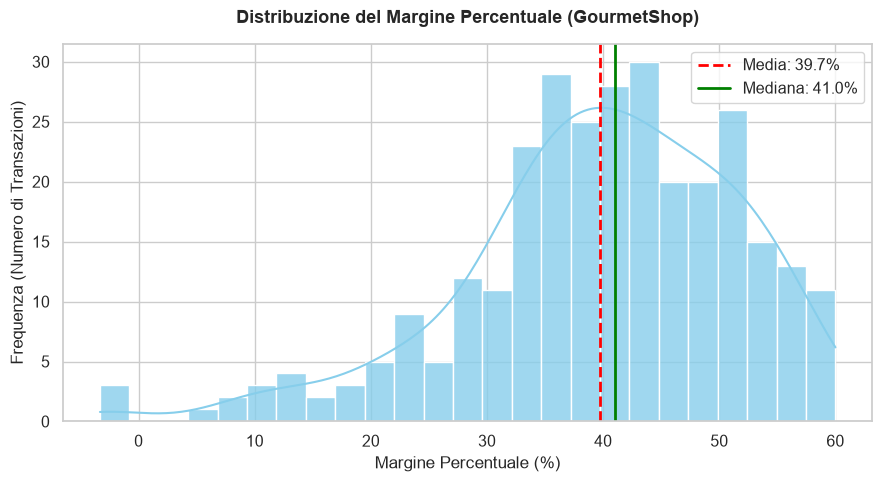

In [ ]:
# Creiamo la figura e l'oggetto asse (ax)
fig, ax = plt.subplots(figsize=(9, 5))

# 1. Creazione dell'istogramma con Seaborn (sui dati del GourmetShop)
sns.histplot(
    data=df, 
    x='margine_percentuale',  # Cambiato con la colonna del tuo nuovo dataset
    bins=25,                  # Richiesto espressamente dalla traccia 6
    kde=True,                 # Attiva la curva KDE richiesta
    color="skyblue", 
    edgecolor="white", 
    alpha=0.8, 
    ax=ax
)

# 2. Calcolo dei nuovi parametri statistici sul margine percentuale
media_marg = df['margine_percentuale'].mean()
mediana_marg = df['margine_percentuale'].median()

# 3. Aggiunta delle linee verticali per Media e Mediana con i nuovi valori
ax.axvline(media_marg, color="red", linestyle="--", linewidth=2, label=f"Media: {media_marg:.1f}%")
ax.axvline(mediana_marg, color="green", linestyle="-", linewidth=2, label=f"Mediana: {mediana_marg:.1f}%")

# 4. Personalizzazione dei testi e delle etichette
ax.set_title("Distribuzione del Margine Percentuale (GourmetShop)", fontsize=13, fontweight="bold", pad=15)
ax.set_xlabel("Margine Percentuale (%)")
ax.set_ylabel("Frequenza (Numero di Transazioni)")
ax.legend()

plt.tight_layout()
plt.show()

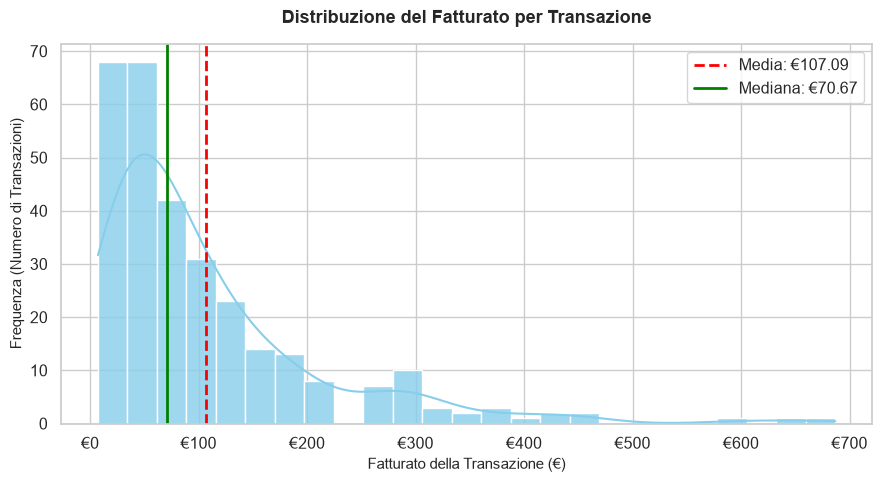

In [ ]:
# =====================================================================
# 6. Istogramma: Distribuzione del Fatturato (GourmetShop)
# =====================================================================

# Generiamo prima la colonna calcolata del fatturato partendo dai dati grezzi
df = df_raw.copy()
df['prezzo_scontato'] = df['prezzo_listino'] * (1 - df['sconto_pct'] / 100)
df['fatturato'] = df['prezzo_scontato'] * df['quantita']

# Creiamo la figura e l'oggetto asse (ax)
fig, ax = plt.subplots(figsize=(9, 5))

# 1. Creazione dell'istogramma con Seaborn sul Fatturato (con bins=25 e curva KDE)
sns.histplot(
    data=df, 
    x='fatturato', 
    bins=25,                  # Richiesto espressamente dalla traccia 6
    kde=True,                 # Attiva la curva KDE richiesta
    color="skyblue", 
    edgecolor="white", 
    alpha=0.8, 
    ax=ax
)

# 2. Calcolo dei parametri statistici (Media e Mediana) sul fatturato
media_fatt = df['fatturato'].mean()
mediana_fatt = df['fatturato'].median()

# 3. Aggiunta delle linee verticali per Media e Mediana con i rispettivi valori in euro
ax.axvline(media_fatt, color="red", linestyle="--", linewidth=2, label=f"Media: €{media_fatt:.2f}")
ax.axvline(mediana_fatt, color="green", linestyle="-", linewidth=2, label=f"Mediana: €{mediana_fatt:.2f}")

# 4. Personalizzazione dei testi, delle etichette e formattazione assi
ax.set_title("Distribuzione del Fatturato per Transazione", fontsize=13, fontweight="bold", pad=15)
ax.set_xlabel("Fatturato della Transazione (€)", fontsize=11)
ax.set_ylabel("Frequenza (Numero di Transazioni)", fontsize=11)

# Formattiamo i valori dell'asse X aggiungendo il simbolo dell'Euro (€)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, pos: f'€{x:,.0f}'))

# Mostriamo la legenda con i valori statistici calcolati
ax.legend()

plt.tight_layout()
plt.show()

7. **Creare un Grafico a Barre:** creare sia barre verticali (`ax.bar()`) sia barre orizzontali (`ax.barh()`), scegliere un colore di evidenziazione per la barra più alta, aggiungere etichette numeriche sopra o accanto alle barre e affiancare due pannelli con `plt.subplots(1, 2)`.

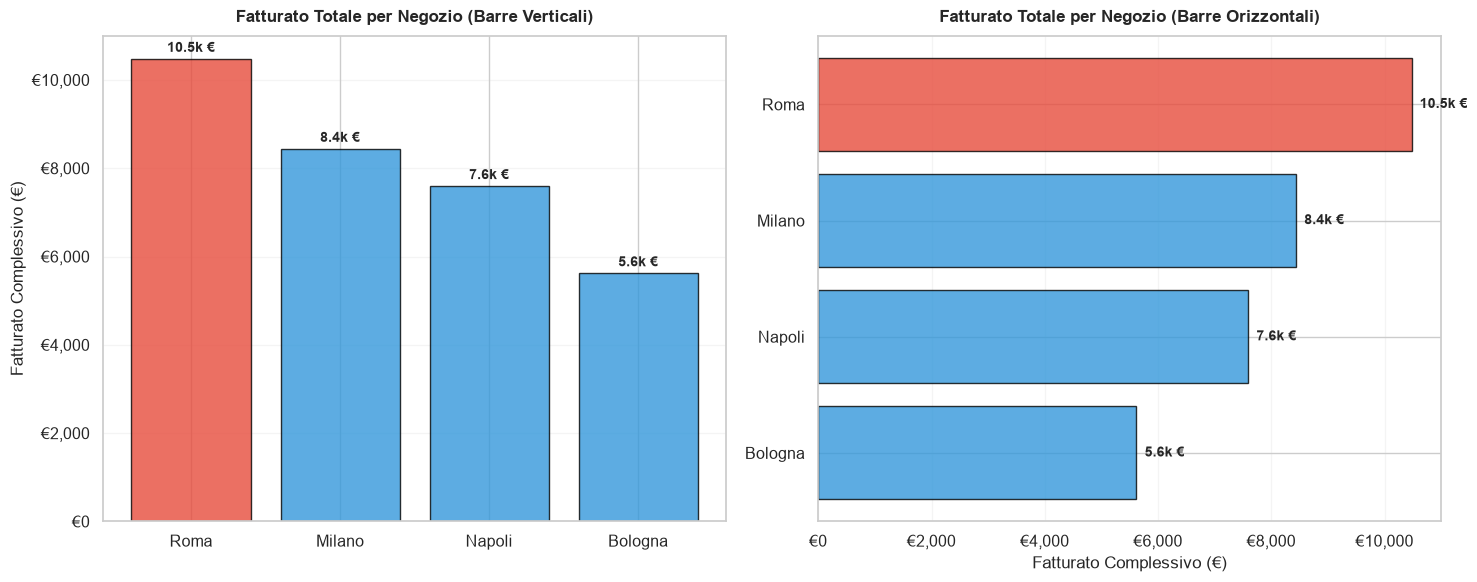

In [ ]:
# 7. Grafico a Barre: Fatturato Totale per Negozio (Verticale vs Orizzontale)


# 1. Prepariamo i dati calcolando il fatturato totale per ogni negozio
conteggio_fatturato = df.groupby('negozio')['fatturato'].sum().reset_index()

# Ordiniamo i dati dal fatturato più alto a quello più basso per una migliore leggibilità
conteggio_fatturato = conteggio_fatturato.sort_values(by='fatturato', ascending=False).reset_index(drop=True)

# Individuiamo l'indice del negozio con il fatturato massimo per evidenziarlo
id_max = conteggio_fatturato['fatturato'].idxmax()

# 2. Creiamo la struttura a due pannelli affiancati (1 riga, 2 colonne)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# --- PANNELLO 1: Barre Verticali (ax.bar) ---
# Definiamo i colori: rosso ('#e74c3c') per il fatturato massimo, blu ('#3498db') per gli altri
colori_v = ['#3498db' if i != id_max else '#e74c3c' for i in range(len(conteggio_fatturato))]

barre1 = ax1.bar(conteggio_fatturato['negozio'], conteggio_fatturato['fatturato'], color=colori_v, edgecolor='black', alpha=0.8)
ax1.set_title("Fatturato Totale per Negozio (Barre Verticali)", fontsize=12, fontweight='bold', pad=10)
ax1.set_ylabel("Fatturato Complessivo (€)")
ax1.grid(True, axis='y', alpha=0.2)

# Aggiunta delle etichette numeriche in formato "k €" (migliaia) SOPRA le barre verticali
for barra in barre1:
    altezza = barra.get_height()
    ax1.annotate(f'{altezza/1000:.1f}k €',
                 xy=(barra.get_x() + barra.get_width() / 2, altezza),
                 xytext=(0, 3),  # Spostamento di 3 punti verso l'alto
                 textcoords="offset points",
                 ha='center', va='bottom', fontsize=10, fontweight='bold')

# --- PANNELLO 2: Barre Orizzontali (ax.barh) ---
colori_h = ['#3498db' if i != id_max else '#e74c3c' for i in range(len(conteggio_fatturato))]

barre2 = ax2.barh(conteggio_fatturato['negozio'], conteggio_fatturato['fatturato'], color=colori_h, edgecolor='black', alpha=0.8)
ax2.set_title("Fatturato Totale per Negozio (Barre Orizzontali)", fontsize=12, fontweight='bold', pad=10)
ax2.set_xlabel("Fatturato Complessivo (€)")
ax2.invert_yaxis()  # Mostra il negozio con più fatturato in cima alla lista
ax2.grid(True, axis='x', alpha=0.2)

# Aggiunta delle etichette numeriche in formato "k €" (migliaia) ACCANTO alle barre orizzontali
for barra in barre2:
    larghezza = barra.get_width()
    ax2.annotate(f' {larghezza/1000:.1f}k €',
                 xy=(larghezza, barra.get_y() + barra.get_height() / 2),
                 xytext=(3, 0),  # Spostamento di 3 punti verso destra
                 textcoords="offset points",
                 ha='left', va='center', fontsize=10, fontweight='bold')

# 3. Formattazione degli assi con la valuta Euro (€) usando mticker
formatter = mticker.FuncFormatter(lambda x, pos: f'€{x:,.0f}')
ax1.yaxis.set_major_formatter(formatter)
ax2.xaxis.set_major_formatter(formatter)

# Ottimizzazione degli spazi della figura
plt.tight_layout()
plt.show()

8. **Creare un Grafico Lineare:** disegnare più linee sullo stesso asse con `ax.plot()` in un ciclo for, assegnare a ogni linea un colore e un marker diverso, forzando l'ordine diverso dei mesi su asse (grafico lineare)

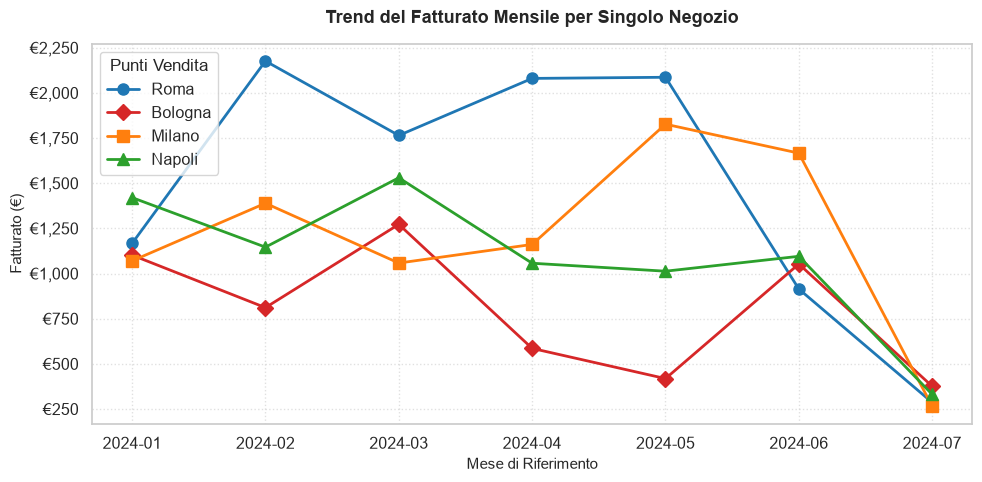

In [ ]:
# =====================================================================
# 8. Creare un Grafico Lineare (Trend Temporale con Ciclo For e Marker)
# =====================================================================

# Creiamo una copia per non sporcare il dataframe originale
df_trend = df.copy()

# SOLUZIONE ALL'ERRORE: Estraiamo la colonna 'mese_str' direttamente dalla colonna 'data'
df_trend['mese_str'] = df_trend['data'].dt.strftime('%Y-%m')

# 1. Prepariamo i dati calcolando il fatturato mensile per ciascun negozio
df_linea = df_trend.groupby(['negozio', 'mese_str'])['fatturato'].sum().reset_index()

# Forziamo l'ordine corretto (cronologico) dei mesi che compariranno sull'asse
mesi_ordinati = sorted(df_linea['mese_str'].unique())

# 2. Inizializziamo la figura e l'asse (approccio orientato agli oggetti)
fig, ax = plt.subplots(figsize=(10, 5))

# Definiamo le mappe per associare a ogni negozio un colore e un marker specifico
colori_mappa = {'Roma': '#1f77b4', 'Milano': '#ff7f0e', 'Napoli': '#2ca02c', 'Bologna': '#d62728'}
marker_mappa = {'Roma': 'o', 'Milano': 's', 'Napoli': '^', 'Bologna': 'D'}

# 3. Disegniamo le linee sullo stesso asse usando un ciclo FOR (richiesto dalla traccia)
for negozio in df_trend['negozio'].unique():
    # Filtriamo il sotto-set di dati relativo al negozio corrente
    dati_negozio = df_linea[df_linea['negozio'] == negozio]
    
    # Riordiniamo i record sui mesi ordinati e riempiamo i mesi vuoti con 0 per non spezzare la linea
    dati_negozio = dati_negozio.set_index('mese_str').reindex(mesi_ordinati)
    dati_negozio['fatturato'] = dati_negozio['fatturato'].fillna(0)
    dati_negozio = dati_negozio.reset_index()
    
    # Tracciamo la linea specifica per il negozio corrente usando ax.plot()
    ax.plot(
        dati_negozio['mese_str'], 
        dati_negozio['fatturato'], 
        label=negozio,
        color=colori_mappa[negozio],
        marker=marker_mappa[negozio],
        linewidth=2,
        markersize=8
    )

# 4. Personalizzazione e formattazione estetica del grafico
ax.set_title("Trend del Fatturato Mensile per Singolo Negozio", fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel("Mese di Riferimento", fontsize=11)
ax.set_ylabel("Fatturato (€)", fontsize=11)

# Abilitiamo la griglia di sfondo per facilitare la lettura dei punti di intersezione
ax.grid(True, linestyle=':', alpha=0.6)

# Formattiamo i valori dell'asse Y aggiungendo il simbolo dell'Euro (€)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, pos: f'€{x:,.0f}'))

# Posizioniamo la legenda in modo chiaro fuori o dentro il grafico
ax.legend(title="Punti Vendita", loc='upper left')

# Ottimizzazione degli spazi della figura
plt.tight_layout()
plt.show()

9. **Creare uno Scatter Plot** e visualizzare indice di correlazione

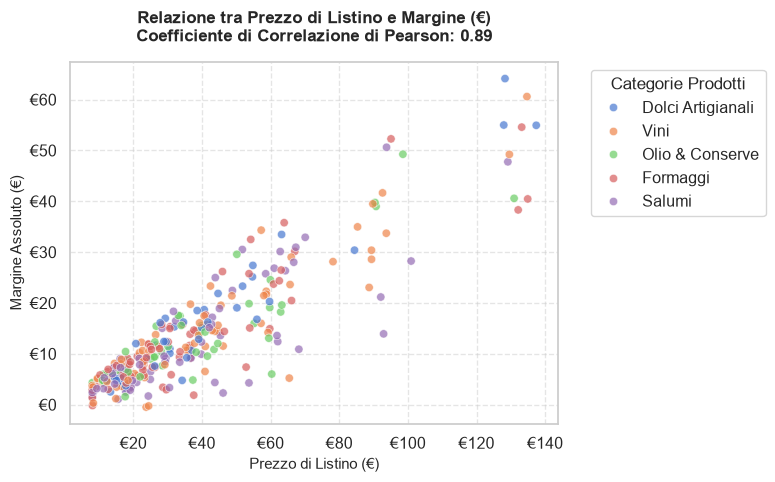

In [ ]:
# =====================================================================
# 9. Creare uno Scatter Plot con Indice di Correlazione
# =====================================================================

# Creiamo una copia sicura del DataFrame per i calcoli dei grafici
df_scatter = df_raw.copy()

# SOLUZIONE ALL'ERRORE: Generiamo le colonne calcolate necessarie se non create prima
df_scatter['prezzo_scontato'] = df_scatter['prezzo_listino'] * (1 - df_scatter['sconto_pct'] / 100)
df_scatter['costo_unitario_negozio'] = df_scatter['prezzo_listino'] * df_scatter['costo_acquisto']

# Calcolo del margine assoluto in euro (Prezzo Scontato - Costo d'acquisto del negozio)
df_scatter['margine_assoluto'] = df_scatter['prezzo_scontato'] - df_scatter['costo_unitario_negozio']

# 1. Calcoliamo matematicamente l'indice di correlazione di Pearson tra le due variabili
indice_correlazione = df_scatter['prezzo_listino'].corr(df_scatter['margine_assoluto'])

# 2. Inizializziamo la figura e l'asse (approccio orientato agli oggetti)
fig, ax = plt.subplots(figsize=(8, 5))

# 3. Creiamo lo scatter plot usando Seaborn
sns.scatterplot(
    data=df_scatter, 
    x='prezzo_listino', 
    y='margine_assoluto', 
    hue='categoria', 
    alpha=0.7, 
    palette='muted',
    ax=ax
)

# 4. Personalizzazione estetica e inserimento dell'indice nel titolo
ax.set_title(
    f"Relazione tra Prezzo di Listino e Margine (€)\n"
    f"Coefficiente di Correlazione di Pearson: {indice_correlazione:.2f}", 
    fontsize=12, 
    fontweight='bold', 
    pad=15
)

ax.set_xlabel("Prezzo di Listino (€)", fontsize=11)
ax.set_ylabel("Margine Assoluto (€)", fontsize=11)

# Abilitiamo la griglia di sfondo
ax.grid(True, linestyle='--', alpha=0.5)

# Formattiamo entrambi gli assi inserendo il simbolo dell'Euro (€)
formatter_euro = mticker.FuncFormatter(lambda x, pos: f'€{x:,.0f}')
ax.xaxis.set_major_formatter(formatter_euro)
ax.yaxis.set_major_formatter(formatter_euro)

# Posizioniamo la legenda delle categorie all'esterno del grafico per non coprire i dati
ax.legend(title="Categorie Prodotti", bbox_to_anchor=(1.05, 1), loc='upper left')

# Ottimizzazione degli spazi della figura per evitare ritagli della legenda esterna
plt.tight_layout()
plt.show()